In [2]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import plot_utils as pu

In [3]:
# configure the backend for matplotlib
# this one should allow zoom:
%matplotlib widget
# to make that work you need: "pip install ipympl" and run "jupyter nbextension enable --py widgetsnbextension"

# this will work without the above dependencies but won't allow zoom
# %matplotlib inline

# this option may work whenever they fix bugs in mpld3
# import mpld3
# mpld3.enable_notebook()

Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0


Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Running model: 2D from bottom
   Negated 2 constraints on 2D from bottom
   Relaxed 2 variables on 2D from bottom
   Gap to target: 0.4006168083848879 : [1.22222222 2.33333333] to [1. 2.]
   Gap to target: 0.07895165203129112 : [0.93894336 2.05005447] to [1. 2.]
   Gap to target: 0.04575787454286506 : [1.01751078 2.04227476] to [1. 2.]
   Gap to target: 0.0734918802431054 : [1.06304597 2.03776589] to [1. 2.]
   Gap to target: 0.13955919299326233 : [1.13618019 2.03052418] to [1. 2.]


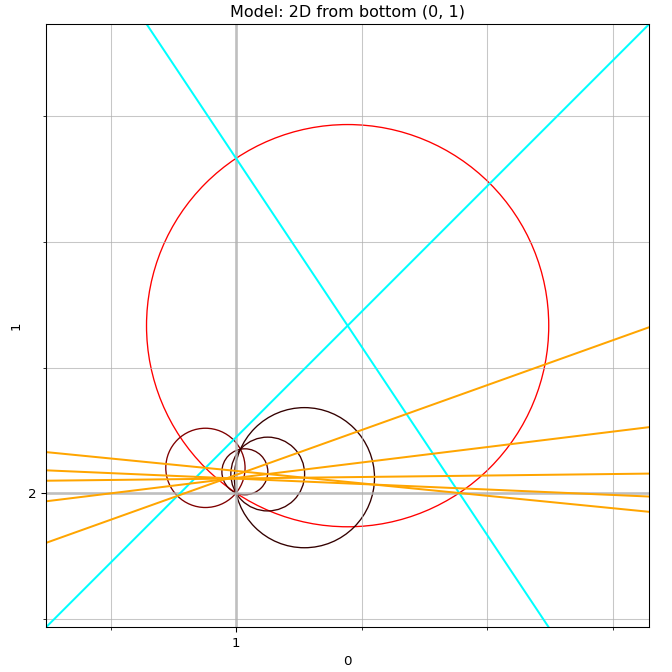

In [18]:
# A function to create cuts given a target point
def add_balas_ball_cut(relaxed: gp.Model, target, integer_vars, integer_idx, plotter, bounds_tightening=False):
    # for each column in the tableau
    # construct a sparse vector for it
    # get the length of that vector via norm1 (plus 1 if we're an int column)
    # add our cut: sum_j(x_j/a_j)
    
    norm = 2
    current = integer_vars.X
    radius = np.linalg.norm(current - target, norm)
    if radius <= relaxed.params.FeasibilityTol:
        return False  # TODO: tolerance should apply to each component individually?
    
    print("   Gap to target:", radius, ":", current[:7], "to", target[:7])
    if plotter is not None:
        plotter.add_ball(current, radius)
    
    basis = gu.read_basis(relaxed)
    tableau, col_to_var, negated_vars = gu.read_tableau(relaxed, basis, extra_rows=1)
    
    # drop the rows of non-integer variables:
    to_drop = [i for i, base in enumerate(basis) if base not in integer_idx]
    tableau = np.delete(tableau, to_drop, axis=0)
    basis = np.delete(basis, to_drop)

    # Conforti has negative vectors with 1 at row=col, with the rest negated.
    # However, empirically, it seems that the opposite is what we really want (gurobi-specific or standardization issue)
    int_cols = [i for i, c in enumerate(col_to_var) if c in integer_idx]
    tableau[-1, int_cols] = -1  # use our extra row to store the col==row -> 1
    lengths = np.linalg.norm(tableau, norm, axis=0)
    lengths /= radius
        
    variables = relaxed.getVars()  # TODO: pass this in as it's expensive
    constraints = relaxed.getConstrs()

    if bounds_tightening:  # assuming this is only true on a feasible target
        for i, base in enumerate(basis):
            all_same_sign = np.all(tableau[i, :] >= 0) or np.all(tableau[i, :] <= 0)  # TODO: find a more efficient call for this
            if all_same_sign and target[integer_idx[base]] > current[integer_idx[base]]:
                new_con = relaxed.addConstr(variables[base] >= target[integer_idx[base]])
                print("Tightened!")
                if plotter is not None:
                    relaxed.update()
                    plotter.add_constraint(new_con, color='green')
            elif all_same_sign and target[integer_idx[base]] < current[integer_idx[base]]:
                new_con = relaxed.addConstr(-variables[base] >= -target[integer_idx[base]])
                print("Tightened!")
                if plotter is not None:
                    relaxed.update()
                    plotter.add_constraint(new_con, color='green')

    def find_variable(index):
        if index < len(variables):
            return variables[index]
        # if only gurobi gave us access to their slack variables...
        # instead, we have to solve for it:
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        # if constraint.Sense != '>':
        #     assert constraint.Sense == '='
        #     return 0.0  # ignore equality constraints with slacks (as gurobi generates a slack for every constraint)
        lhs, rhs = relaxed.getRow(constraint), constraint.RHS
        # if cons_idx in negated_vars:
        #     return rhs - lhs
        return lhs - rhs
    
    summed_terms = gp.quicksum(lengths[i] * find_variable(j) for i, j in enumerate(col_to_var))
    new_con = relaxed.addConstr(summed_terms >= 1)
    if plotter is not None:
        relaxed.update()
        plotter.add_constraint(new_con)
    return True

# a function to run cuts against the nearest integer:
def run_cuts_to_nearest_int(instances, cut_function, loops=5, graph_2D_3D=True):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        model.params.Method = 1
        gu.standardize_lt_to_gt(model)
        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        plotter = pu.create(model) if graph_2D_3D else None
        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break
            nearest = gu.nearest_integer(int_vars)
            if not cut_function(model, nearest, int_vars, int_idx, plotter):
                print("   Final score of relaxed:", model.getObjective().getValue())
                break
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples:
run_cuts_to_nearest_int(list(el.get_instances().values())[0:1], add_balas_ball_cut)

Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Running model: 2D from bottom
   Negated 2 constraints on 2D from bottom
   Relaxed 2 variables on 2D from bottom
   Gap to target: 0.4006168083848879 : [1.22222222 2.33333333] to [1. 2.]
   CUT: [-0.09009805 -0.90990195] [1.22222222 2.33333333] 0.28327886186626583
   Gap to target: 0.07895165203129106 : [0.93894336 2.05005447] to [1. 2.]
   CUT: [ 0.26335759 -0.73664241] [0.93894336 2.05005447] 0.026422189147463616
   Gap to target: 0.04575787454286539 : [1.01751078 2.04227476] to [1. 2.]
   CUT: [ 0. -1.] [1.01751078 2.04227476] 0.015404096695738282
   Gap to target: 0.03709690143853911 : [0

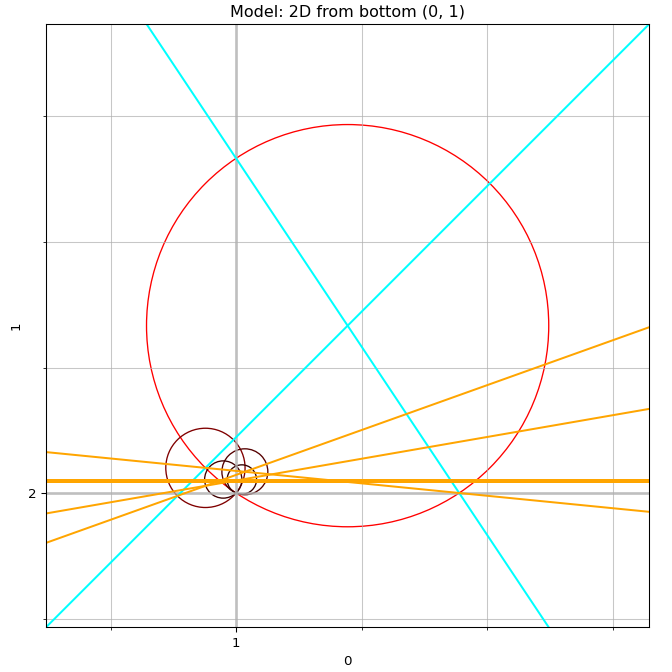

Running model: 2D from top
   Negated 0 constraints on 2D from top
   Relaxed 2 variables on 2D from top
   Gap to target: 0.4006168083848878 : [1.22222222 2.33333333] to [1. 2.]
   CUT: [ 0. -1.] [1.22222222 2.33333333] -0.0672834750515543
   Gap to target: 0.43812410124320095 : [1.17736657 2.40061681] to [1. 2.]
   CUT: [-0.39362843 -0.60637157] [1.17736657 2.40061681] -0.12538493198409528
   Gap to target: 0.6079842181201779 : [1.37074948 2.48186059] to [1. 2.]
   CUT: [ 0. -1.] [1.37074948 2.48186059] -0.12612362507560115
   Gap to target: 0.6328975096425108 : [1.49687311 2.60798422] to [1. 3.]
   CUT: [-0.29289322  0.70710678] [1.49687311 2.60798422] 0.18537138877821308
   Gap to target: 0.3177496953938688 : [1.05473806 2.68700062] to [1. 3.]
   CUT: [0.08407889 0.91592111] [1.05473806 2.68700062] 0.1360561608922762


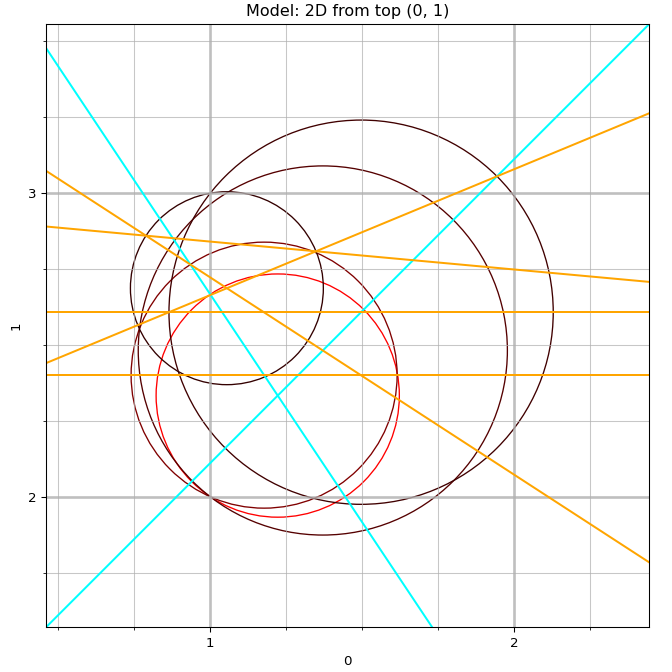

Running model: 2D from bottom (manual slacks)
   Negated 0 constraints on 2D from bottom (manual slacks)
   Relaxed 2 variables on 2D from bottom (manual slacks)
   Gap to target: 0.4006168083848878 : [1.22222222 2.33333333] to [1. 2.]
   CUT: [ 0. -1.] [1.22222222 2.33333333] -0.0672834750515543
   FAILED! Status: 3


In [21]:
# a function to find the hyperplane closest to a point
def compute_hyperplane_via_lp(x0, b0, tableau, basis, col_to_var, int_idx):
    m = gp.Model()
    b = m.addVar(lb=-gp.GRB.INFINITY)
    w = m.addMVar(x0.shape, lb=-gp.GRB.INFINITY)
    wn = m.addVar()
    m.addConstr(wn == gp.norm(w, 1))
    m.addConstr(wn == 1)  # optional
    z = m.addVar()
    m.addConstr(z >= x0 @ w - b - b0)
    m.addConstr(z >= -x0 @ w + b + b0)
    m.setObjective(z)
    # our w represents all integer variables,
    # so not all columns in the tableau have a corresponding integer var.
    for i, vec in enumerate(tableau.T):
        cv = col_to_var[i]
        w_idx = int_idx.get(cv, -1)
        if w_idx >= 0:
            m.addConstr(vec[:-1] @ w[basis] + vec[-1] * w[w_idx] <= b)
        else:
            assert vec[-1] == 0.0
            m.addConstr(vec[:-1] @ w[basis] <= b)
    m.params.LogToConsole = 0
    m.optimize()
    assert m.Status == gp.GRB.OPTIMAL
    return w.X, b.X

# create a function to do cuts via LP:
def add_lp_ball_cut(relaxed: gp.Model, target, integer_vars, integer_idx, plotter):
    
    norm = 2
    current = integer_vars.X
    radius = np.linalg.norm(current - target, norm)
    if radius <= relaxed.params.FeasibilityTol:
        return False  # TODO: tolerance should apply to each component individually?
    
    if plotter is not None:
        plotter.add_ball(current, radius)
    print("   Gap to target:", radius, ":", current[:4], "to", target[:4])
    
    basis = gu.read_basis(relaxed)
    tableau, col_to_var, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=1)
    # tableau[negated_rows, :] *= -1.0  # only happens on slack vars?
    # gu.validate_corner(relaxed, basis, tableau[:-1], col_to_var)
    
    # drop the rows of non-integer variables:
    to_drop = [i for i, base in enumerate(basis) if base not in integer_idx]
    tableau = np.delete(tableau, to_drop, axis=0)
    basis = np.delete(basis, to_drop)
    
    # integer_idx goes from var num to index in integer_vars
    int_cols = [i for i, c in enumerate(col_to_var) if c in integer_idx]
    tableau[-1, int_cols] = -1  # use our extra row to store the col==row -> 1
    
    # for cvi, cv in enumerate(col_to_var):
    #     if cv in integer_idx:
    #         if integer_vars[integer_idx[cv]].VBasis == -2:
    #             tableau[:, cvi] *= -1
    lengths = np.linalg.norm(tableau, norm, axis=0)
    
    # normalize the columns:
    tableau *= radius
    tableau /= lengths

    # generate the LP to find the hyperplane
    int_basis = [integer_idx[base] for base in basis]
    w, b = compute_hyperplane_via_lp(target - current, radius, tableau, int_basis, col_to_var, integer_idx)
    print("   CUT:", w, current, b)

    # add the cut:
    if b >= 0:
        new_con = relaxed.addConstr(w @ (integer_vars - current) >= b)
    else:
        new_con = relaxed.addConstr(w @ (current - integer_vars) >= -b)
    if plotter is not None:
        relaxed.update()
        plotter.add_constraint(new_con)

    return True

run_cuts_to_nearest_int(list(el.get_instances().values())[0:3], add_lp_ball_cut)

Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Running model: Book example 6.3
   Negated 3 constraints on Book example 6.3
   Relaxed 3 variables on Book example 6.3
   Gap to target: 1.224744871391589 : [0.5 0.5 1. ] to [-0. -0. -0.]
   Gap to target: 0.6270421397473425 : [0.5        1.15465367 0.34534633] to [0. 1. 0.]
   Gap to target: 0.5684581040397488 : [ 0.59803942  1.40196058 -0.        ] to [ 1.  1. -0.]
   Gap to target: 0.29425556733671443 : [0.83011147 0.93781648 0.23207205] to [1. 1. 0.]
   Gap to target: 0.39762037566168823 : [0.84988979 0.78684142 0.30022043] to [1. 1. 0.]
   Gap to target: 0.4562118350919343 : [0.5728481  

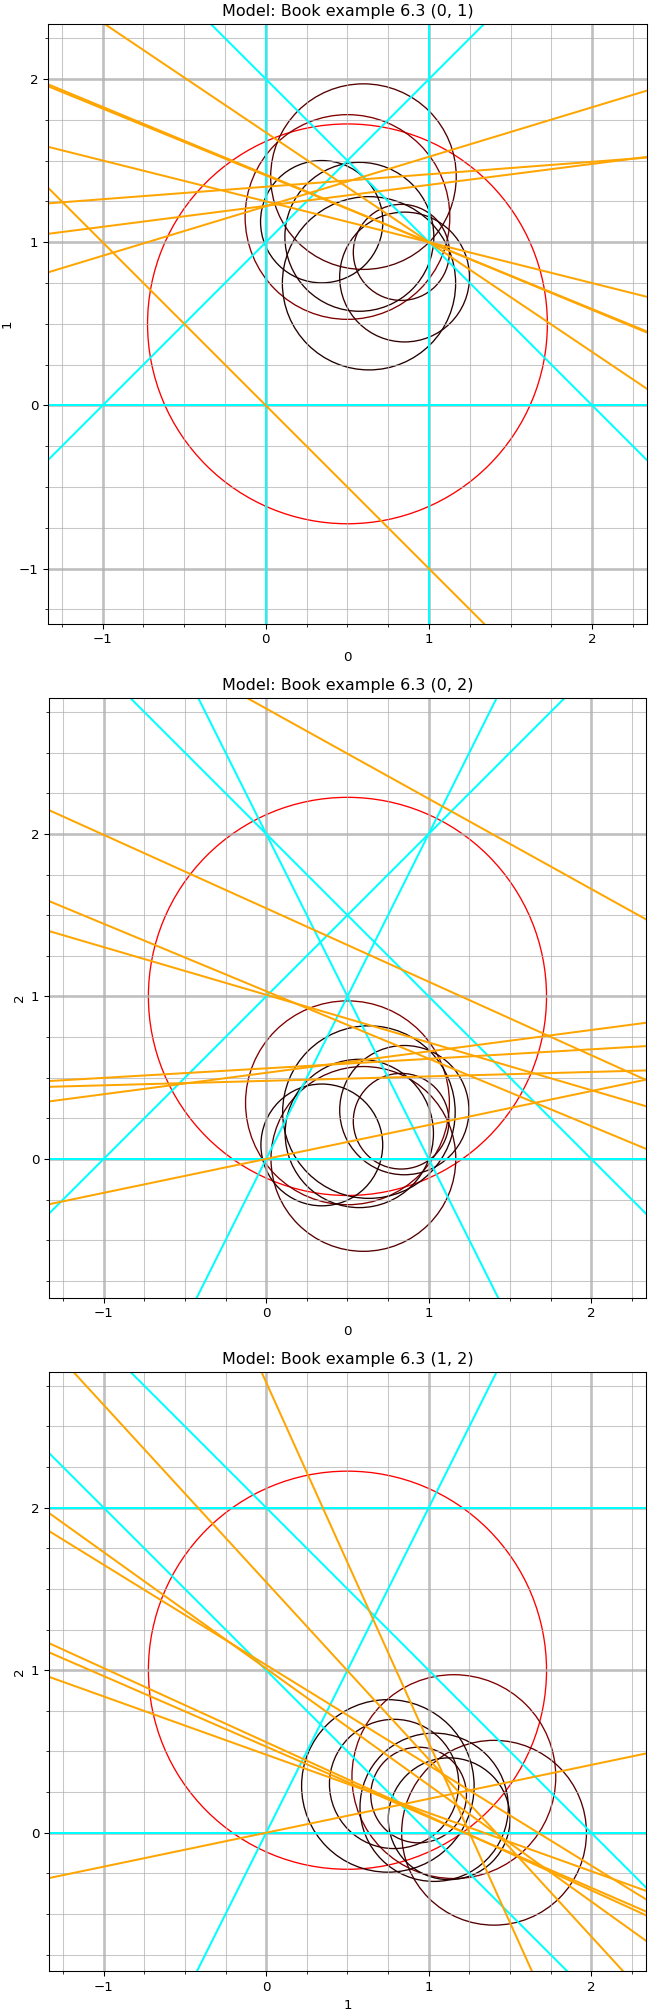

In [23]:
def run_cuts_to_relaxed_sol(instances, cut_function, loops=8):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        gu.standardize_lt_to_gt(model)
        plotter = pu.create(model)

        exact_model = model.copy()
        exact_model.update()
        exact_vars = gp.MVar.fromlist([v for v in exact_model.getVars() if v.VType != 'C'])
        z = exact_model.addMVar(exact_vars.shape, lb=-gp.GRB.INFINITY)
        exact_model.setObjective(z.sum(), gp.GRB.MINIMIZE)

        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break

            relaxed_x = int_vars.X
            ca = exact_model.addConstr(z >= exact_vars - relaxed_x)
            cb = exact_model.addConstr(z >= relaxed_x - exact_vars)
            exact_model.optimize()
            assert exact_model.Status == gp.GRB.OPTIMAL

            if not cut_function(model, exact_vars.X, int_vars, int_idx, plotter, False):
                print("   Final score of relaxed:", model.getObjective().getValue())
                break

            exact_model.remove(ca)
            exact_model.remove(cb)
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples:
run_cuts_to_relaxed_sol(list(el.get_instances().values())[3:], add_balas_ball_cut)

In [22]:
miplib_instances = ml.get_instances()
miplib_subset = [miplib_instances['air05'], miplib_instances['markshare2']]  # mas76
run_cuts_to_relaxed_sol(miplib_subset, add_balas_ball_cut)

Read MPS format model from file mip2017_benchmark/revised-submissions/miplib2010_publically_available/instances/air05.mps.gz
Reading time = 0.02 seconds
air05: 426 rows, 7195 columns, 52121 nonzeros
Running model: air05
   Negated 0 constraints on air05
   Relaxed 7195 variables on air05
   Gap to target: 5.313768418382032 : [0.         0.         0.20409116 0.         0.88092007 0.
 0.67214538] to [ 0. -0.  1. -0.  1. -0.  1.]
   Gap to target: 5.319227087375193 : [0.         0.         0.18763769 0.         0.88024292 0.
 0.66562702] to [-0. -0.  1. -0.  1. -0.  1.]
   Gap to target: 5.2907673592094095 : [0.         0.         0.20363738 0.00198516 0.86326756 0.
 0.64165554] to [-0. -0.  1. -0.  1. -0.  1.]
   Gap to target: 5.399036271936402 : [0.         0.         0.19740122 0.0568843  0.88587546 0.
 0.64517392] to [-0. -0.  1. -0.  1. -0.  1.]
   Gap to target: 5.346570363363677 : [0.         0.         0.19653588 0.06079611 0.85018933 0.
 0.61889646] to [-0. -0.  1.  0.  1. -0. 